# Import des librairies

85095 fichiers chargés .
Dimension du dataset : (85095, 7)
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041904  0.037187  0.258505   37.0           1      0           1
2  0.041739  0.037219  0.258619   67.0           1      0           1
3  0.041446  0.037573  0.258731  101.0           1      0           1
4  0.041303  0.037331  0.258830  132.0           1      0           1
Sous-echantillonnage des données...


c:\Users\lechef\OneDrive - Haute Ecole Louvain en Hainaut\Bureau\Projet_IA\Gesture-Recognition-Project\explore_data.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['subject_id', 'digit', 'repetition'])


Terminé !
Points originaux     : 85,095
Points sous-échant.  : 36,912
Réduction effective  : 56.6%

 Aperçu des ratios de réduction par groupe :
       subject_id       digit  repetition  n_original  n_downsampled  \
count  764.000000  764.000000  764.000000  764.000000     764.000000   
mean     5.945026    4.286649    5.413613   94.986911      48.314136   
std      2.824182    2.910690    2.881063   20.939589      10.451699   
min      1.000000    0.000000    1.000000   66.000000      34.000000   
25%      4.000000    2.000000    3.000000   81.000000      41.000000   
50%      6.000000    4.000000    5.000000   90.000000      46.000000   
75%      8.000000    6.000000    8.000000  105.250000      53.250000   
max     10.000000    9.000000   10.000000  190.000000      96.000000   

            ratio  
count  764.000000  
mean     0.509066  
std      0.004164  
min      0.493506  
25%      0.505618  
50%      0.508265  
75%      0.511905  
max      0.522388  
Subject ID: 1, Digit: 0, N

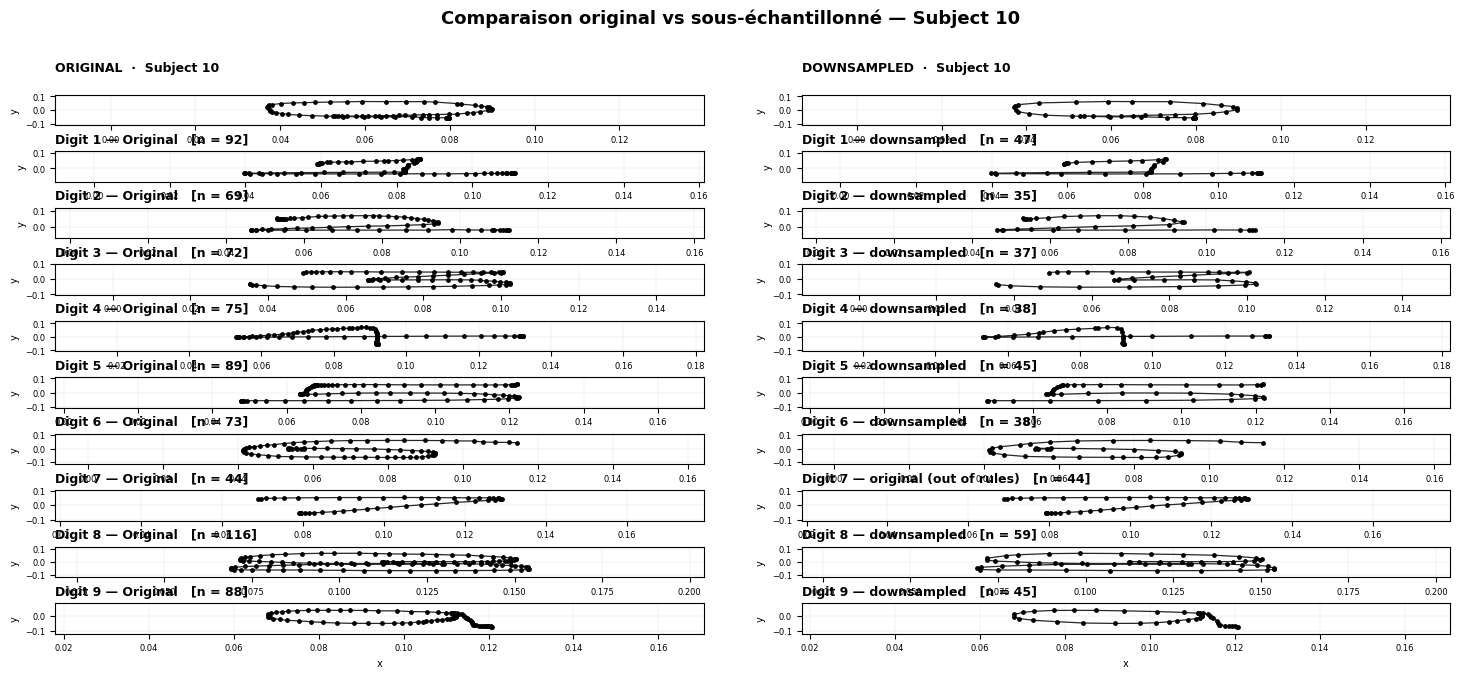

Affichage terminé.


In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d 

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

#import locaux

from import_dataset import load_dataset
from explore_data import downsample_data, plot_xy_grid
from Edit_distance import edit_distance

# Chargement du Dataset

In [2]:
#BASE_DIR = os.path.dirname(os.path.abspath(__file__)) le __file__ fait planter le code dans un script python, mais dans un notebook il n'est pas défini, du coup on utilise os.getcwd() pour prendre le répertoire courant du notebook
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "Dataset", "Domain1_csv")

#print(len(os.listdir(DATA_DIR))) validation que tous les chiffiers ont été chargés

dataset = pd.concat(load_dataset(DATA_DIR), ignore_index=True) 

print(f"{len(dataset)} fichiers chargés .") 
print(f"Dimension du dataset : {dataset.shape}")

print(dataset.head())

# ligne a décommenter pour sauvegarder le dataset traité dans un fichier csv
dataset.to_csv(os.path.join(BASE_DIR, "Dataset", "Aggregated_csv", "Domain1_processed_dataset.csv"), index=False) 


85095 fichiers chargés .
Dimension du dataset : (85095, 7)
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041904  0.037187  0.258505   37.0           1      0           1
2  0.041739  0.037219  0.258619   67.0           1      0           1
3  0.041446  0.037573  0.258731  101.0           1      0           1
4  0.041303  0.037331  0.258830  132.0           1      0           1


# Sous-échantillonnage et visualisation 

Sous-echantillonnage des données...


C:\Users\lechef\AppData\Local\Temp\ipykernel_30164\628101747.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['subject_id', 'digit', 'repetition'])


Terminé !
Points originaux     : 85,095
Points sous-échant.  : 36,912
Réduction effective  : 56.6%

 Aperçu des ratios de réduction par groupe :
       subject_id       digit  repetition  n_original  n_downsampled  \
count  764.000000  764.000000  764.000000  764.000000     764.000000   
mean     5.945026    4.286649    5.413613   94.986911      48.314136   
std      2.824182    2.910690    2.881063   20.939589      10.451699   
min      1.000000    0.000000    1.000000   66.000000      34.000000   
25%      4.000000    2.000000    3.000000   81.000000      41.000000   
50%      6.000000    4.000000    5.000000   90.000000      46.000000   
75%      8.000000    6.000000    8.000000  105.250000      53.250000   
max     10.000000    9.000000   10.000000  190.000000      96.000000   

            ratio  
count  764.000000  
mean     0.509066  
std      0.004164  
min      0.493506  
25%      0.505618  
50%      0.508265  
75%      0.511905  
max      0.522388  
Subject ID: 1, Digit: 0, N

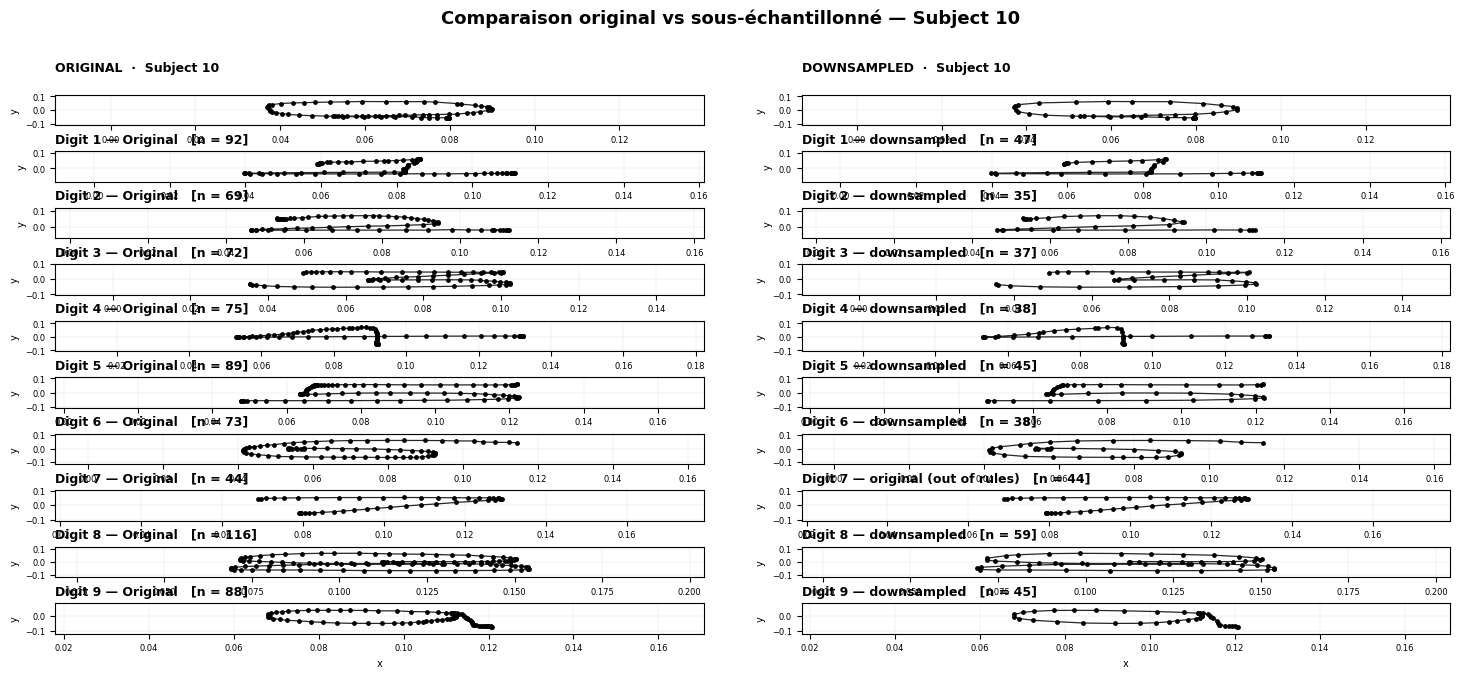

Affichage terminé.


In [3]:
df = dataset.copy() # pour éviter de modifier le dataset original

print("Sous-echantillonnage des données...")

df_result = (
    df.groupby(['subject_id', 'digit', 'repetition']) 
    .apply(downsample_data)
    .reset_index(drop=True)
)

df_downsampled = df_result[df_result['downsampled'] == True].drop(columns=['downsampled'])

original_count = len(df) 
downsampled_count = len(df_downsampled)
reduction = (1-downsampled_count/original_count)*100

print(f"Terminé !")
print(f"Points originaux     : {original_count:,}")
print(f"Points sous-échant.  : {downsampled_count:,}")
print(f"Réduction effective  : {reduction:.1f}%")

# --- Vérification par groupe ---
summary = df.groupby(["subject_id", "digit", "repetition"]).size().reset_index(name="n_original")
summary_new = df_downsampled.groupby(["subject_id", "digit", "repetition"]).size().reset_index(name="n_downsampled")

summary["was_downsampled"] = df_result.groupby(["subject_id", "digit", "repetition"])["downsampled"].first().values

summary = summary.merge(summary_new, on=["subject_id", "digit", "repetition"])
summary["ratio"] = summary["n_downsampled"] / summary["n_original"]

skipped = (~summary["was_downsampled"]).sum()
print("\n Aperçu des ratios de réduction par groupe :")
print(summary.describe())

# ligne a décommenter pour sauvegarder le dataset traité dans un fichier csv
#df_downsampled.to_csv(os.path.join(BASE_DIR, "Dataset", "Domain1_aggregated_csv", "Domain1_downsampled_dataset.csv"), index=False)

# prendre un subset 
subset = df[(df['subject_id'] == 1) & (df['digit'] == 0)]

for (subject_id, digit,rep), group in subset.groupby(['subject_id', 'digit', 'repetition']):
   print(f"Subject ID: {subject_id}, Digit: {digit}, Number of rows: {len(group)}")


# code pour afficher les points avant et après le sous-échantillonnage pour un groupe spécifique (par exemple, subject_id=1, digit=0)

Subject = 1 
Line_color = 'black'

Digits = sorted(df['digit'].unique())
N_rows = len(Digits)
N_columns = 2

plot_xy_grid(subject=10)


# Etude par Edit-Distance

## Clustering - Analyse nombre de cluster par la Méthode du coude

Standardisation individuelle des gestes en cours...


C:\Users\lechef\AppData\Local\Temp\ipykernel_30164\1376243556.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_downsampled = df_downsampled.groupby(['subject_id', 'digit', 'repetition'], group_keys=False).apply(standardize_group)


Prêt ! 36912 points 3D vont être analysés.
K-Means : Test des k de 2 à 30 ...


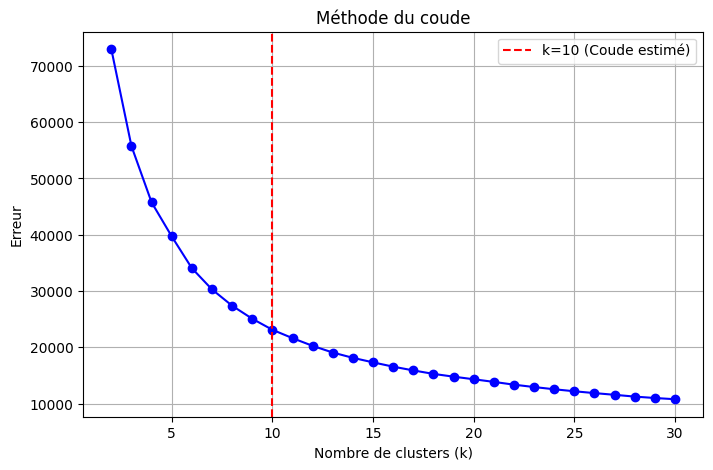

In [4]:
print("Standardisation individuelle des gestes en cours...")

# 1. La standardisation PAR GESTE 
def standardize_group(group):
    coords = group[['x', 'y', 'z']].values 
    gravity_center = np.mean(coords, axis=0)
    std = np.std(coords, axis=0)
    std[std == 0] = 1 # Sécurité pour éviter ladivision par zéro
    
    coords_std = (coords - gravity_center) / std
    
    # On ajoute directement les colonnes au groupe
    group['x_std'] = coords_std[:, 0]
    group['y_std'] = coords_std[:, 1]
    group['z_std'] = coords_std[:, 2]
    return group

# On l'applique sur chaque geste du df_downsampled 

df_downsampled = df_downsampled.groupby(['subject_id', 'digit', 'repetition'], group_keys=False).apply(standardize_group) 

# 2. Extraction des points 
points_3d = df_downsampled[['x_std', 'y_std', 'z_std']].values # on prend les colonnes standardisées pour faire du clustering
print(f"Prêt ! {points_3d.shape[0]} points 3D vont être analysés.")

# 3. Méthode du coude
def plot_elbow_method(X, max_k=30): 
    errors = []
    k_values = range(2, max_k + 1)
    
    print(f"K-Means : Test des k de 2 à {max_k} ...")
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X) 
        errors.append(kmeans.inertia_) # inertia_ est la somme des distances au carré entre les points et leur centre de cluster (plus c'est bas, mieux c'est)

    plt.figure(figsize=(8,5))
    plt.plot(k_values, errors, marker='o', color='b')
    
    # On ajoute une ligne pointillée sur k=10 pour le mettre en évidence
    plt.axvline(x=10, color='r', linestyle='--', label='k=10 (Coude estimé)')
    
    plt.title('Méthode du coude')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel("Erreur")
    plt.legend()
    plt.grid(True)
    plt.show()

# On lance le test !
plot_elbow_method(points_3d)

### Traduction des clusters en alphabet

In [5]:
print("Création de l'alphabet et traduction...")

# 1. Entraînement du modèle définitif avec le k=10 (choisi à partir de la méthode du coude)
k_optimal = 10
points_3d = df_downsampled[['x_std', 'y_std', 'z_std']].values

#ajouter un split train-test

print(f"Apprentissage des {k_optimal} lettres de l'alphabet spatial...")
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_final.fit(points_3d)

# 2. La fonction de traduction (de points 3D vers du Texte)
def traduire_en_lettres(group):
    # On extrait les points standardisés du geste
    coords = group[['x_std', 'y_std', 'z_std']].values
    
    # Le K-Means attribue chaque point à son cluster le plus proche (de 0 à 12)
    labels = kmeans_final.predict(coords)
    
    # On transforme le numéro en lettre (0 -> A, 1 -> B, ..., 12 -> M)
    # L'astuce : chr(65) donne 'A' en informatique (code ASCII)
    lettres = [chr(65 + label) for label in labels]
    
    # On colle toutes les lettres pour faire un seul mot (ex: "AABBCCC...")
    mot = "".join(lettres)
    
    # On retourne une petite boîte contenant notre mot
    return pd.Series({'mot_traduit': mot})

print("Traduction des gestes en texte ...")

# 3. Application de la traduction geste par geste
# utilisation de groupby pour ne pas mélanger les gestes !
df_mots = df_downsampled.groupby(['subject_id', 'digit', 'repetition']).apply(traduire_en_lettres).reset_index()

# 4. Sauvegarde du Dictionnaire Final
output_dir = os.path.join(BASE_DIR, "Dataset", "Aggregated_csv")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "Domain1_dictionnaire_mots.csv")

df_mots.to_csv(output_path, index=False)

print(f"Terminé ! Le dictionnaire est sauvegardé ici : {output_path}")
print("\n Aperçu des données (prêtes pour l'Edit Distance) :")
print(df_mots.head(10))

Création de l'alphabet et traduction...
Apprentissage des 10 lettres de l'alphabet spatial...
Traduction des gestes en texte ...


C:\Users\lechef\AppData\Local\Temp\ipykernel_30164\1762997618.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mots = df_downsampled.groupby(['subject_id', 'digit', 'repetition']).apply(traduire_en_lettres).reset_index()


Terminé ! Le dictionnaire est sauvegardé ici : c:\Users\lechef\OneDrive - Haute Ecole Louvain en Hainaut\Bureau\Projet_IA\Gesture-Recognition-Project\Dataset\Aggregated_csv\Domain1_dictionnaire_mots.csv

 Aperçu des données (prêtes pour l'Edit Distance) :
   subject_id  digit  repetition  \
0           1      0           1   
1           1      0           2   
2           1      0           3   
3           1      0           4   
4           1      0           5   
5           1      0           6   
6           1      0           7   
7           1      0           8   
8           1      0           9   
9           1      0          10   

                                         mot_traduit  
0  AAAAAAAAAAAHHHHHHHHHHCCCCCCCCCFFFFFBBBBBBBBGGG...  
1  GGGGGGEEEEEEAAAAHHHHHHHHHHHHHCCCCCCCCCFFFFBBBB...  
2  GGGGGGGGEEEEEEAAAAAAAAHHHHHHHHHHHHHHHHHHCCCCCC...  
3  EEEEAAAAAAAHHHHHHHCCCCCCCCFFBBBBBBGGGGGEEEEEEA...  
4  HHHHHHHHCCCCCCCCFFBBBBBBBBGGGGGGGGEEEEEAAAAAAA...  
5  HHHHHHHHCCCCCC

### Application de l'édit distance

In [6]:
def knn(test_gesture, training_gestures, k= 3):
    distances = []
    for train_gesture in training_gestures:
        dist = edit_distance(test_gesture['mot_traduit'], train_gesture['mot_traduit'])
        distances.append((dist, train_gesture['digit']))
    
    # Trier par distance et prendre les k plus proches
    distances.sort(key=lambda x: x[0])
    nearest_neighbors = distances[:k]
    
    # Prendre la classe majoritaire parmi les voisins
    classes = [neighbor[1] for neighbor in nearest_neighbors]
    predicted_class = max(set(classes), key=classes.count)
    
    return predicted_class

Cross validation (User Independant)

In [7]:
def split_user(data):

    users = {}
    for gesture in data:
        user_id = gesture['subject_id']
        if user_id not in users:
            users[user_id] = []
        users[user_id].append(gesture)
    return users

gestures_user = split_user(df_mots.to_dict(orient='records'))

for user_id, gestures in gestures_user.items():
    print(f"User {user_id} has {len(gestures)} gestures.")

User 1 has 90 gestures.
User 2 has 10 gestures.
User 3 has 85 gestures.
User 4 has 44 gestures.
User 5 has 90 gestures.
User 6 has 92 gestures.
User 7 has 91 gestures.
User 8 has 85 gestures.
User 9 has 88 gestures.
User 10 has 89 gestures.


Testing on user 1...
Accuracy for user 1: 0.98
Testing on user 2...
Accuracy for user 2: 0.30
Testing on user 3...
Accuracy for user 3: 0.98
Testing on user 4...
Accuracy for user 4: 0.86
Testing on user 5...
Accuracy for user 5: 0.82
Testing on user 6...
Accuracy for user 6: 0.65
Testing on user 7...
Accuracy for user 7: 0.76
Testing on user 8...
Accuracy for user 8: 0.91
Testing on user 9...
Accuracy for user 9: 0.89
Testing on user 10...
Accuracy for user 10: 0.85
 Moyenne des Accuracy: 0.80
Ecart-type des accuracies par utilisateur : 0.19 


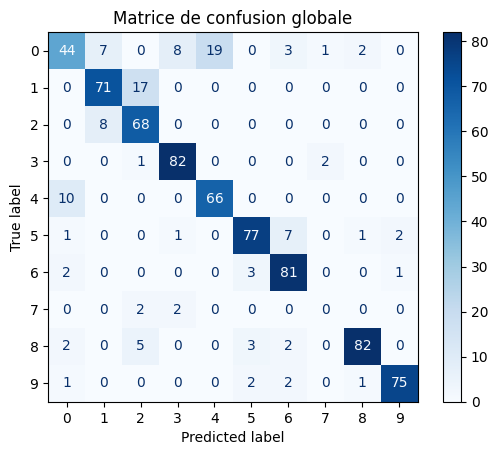

In [8]:
def cross_validation_user_independent(users, k=3, plot_confusion=True):
    accuracies = []
    all_y_true = []
    all_y_pred = []
    
    for test_user in sorted(users.keys()):
        print(f"Testing on user {test_user}...")

        test_gestures = users[test_user]
        training_gestures = []

        for train_user in users:
            if train_user != test_user:
                training_gestures.extend(users[train_user]) 
        
        y_true = [gesture['digit'] for gesture in test_gestures]
        y_pred = [knn(gesture, training_gestures, k=k) for gesture in test_gestures]


        accur = accuracy_score(y_true, y_pred)
        print(f"Accuracy for user {test_user}: {accur:.2f}")
        accuracies.append(accur)

        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)
    
    overall_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f" Moyenne des Accuracy: {overall_accuracy:.2f}")
    print(f"Ecart-type des accuracies par utilisateur : {std_accuracy:.2f} ")

    if plot_confusion:
        cm = confusion_matrix(all_y_true, all_y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(all_y_true)))
        disp.plot(cmap=plt.cm.Blues)
        plt.title("Matrice de confusion globale")
        plt.show()
    
    return overall_accuracy, std_accuracy

accuracy, std_accuracy = cross_validation_user_independent(gestures_user, k=3)
